# 07 — WCS Center Uncertainty

**Purpose:** Quantify how uncertain the WCS solution is at the image center — both
the sky position (RA, Dec) and the local north angle — using two complementary
methods:

1. **Fiducial comparison**: solves at tweak_order 4 vs 5 establish an inter-order
   systematic.
2. **Spatial jackknife**: omit spatial thirds/halves of the source list, re-solve,
   measure spread across 12 subsets (all order 5).
3. **Bootstrap resampling**: N_BOOT=50 random 80%-subsets without replacement;
   gives a statistical floor independent of spatial structure.
4. **Residual vector field**: quiver plot showing where each subset's WCS
   disagrees with the fiducial — highlights any spatial pattern.
5. **Final summary**: adopted uncertainty = quadrature sum of bootstrap std,
   order systematic, and jackknife systematic.

All subset solves use `platesolve_xylist()` with the same source list extracted
once from the full image. Results are cached to `out/wcs_uncertainty_tests/`.

In [16]:
import time

In [1]:
import sys, warnings, pickle, itertools
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter
from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u

ROOT      = Path('..').resolve()
FITS_PATH = sorted((ROOT / 'data').glob('*.fit'))[0]
sys.path.insert(0, str(ROOT))

from extractor.stars import extract_stars
from extractor.platesolve import platesolve_xylist, wcs_summary, has_sip

OUT_DIR = ROOT / 'out' / 'wcs_uncertainty_tests'
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#111', 'axes.facecolor': '#111',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': '#ccc',  'ytick.color': '#ccc',
    'axes.edgecolor': '#555', 'axes.titlecolor': 'white',
    'legend.facecolor': '#1e1e1e', 'legend.edgecolor': '#555',
    'grid.color': '#333', 'grid.alpha': 0.4,
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'savefig.facecolor': '#111', 'savefig.dpi': 150,
})

with afits.open(FITS_PATH) as hdul:
    image  = hdul[0].data.astype(float)
    orig_header = hdul[0].header.copy()
ny, nx = image.shape
xc, yc = (nx - 1) / 2.0, (ny - 1) / 2.0

# Display stretch (reused in plots)
_bg  = gaussian_filter(image.astype(np.float32), sigma=50)
_proc = np.clip(image.astype(np.float32) - _bg, 0, None)
_lo, _hi = np.percentile(_proc[np.isfinite(_proc)], [0.5, 99.5])
disp = np.arcsinh(np.clip(_proc, _lo, _hi))
_vlo, _vhi = float(np.arcsinh(_lo)), float(np.arcsinh(_hi))

print(f'Image    : {FITS_PATH.name}  ({nx} x {ny} px)')
print(f'Center   : ({xc:.1f}, {yc:.1f}) px')
print(f'Out dir  : {OUT_DIR}')

Image    : fuji6_asi178_100_15s.fit  (3096 x 2080 px)
Center   : (1547.5, 1039.5) px
Out dir  : C:\Users\bassd\Research\Spectra Angle\spectrangle\out\wcs_uncertainty_tests


In [2]:
# Extract stars once — reused by all subset solves.
# Cache to avoid re-running DAOStarFinder every kernel restart.
_src_cache = OUT_DIR / 'sources_full.pkl'
if _src_cache.exists():
    with open(_src_cache, 'rb') as fh:
        all_xs, all_ys, all_fluxes = pickle.load(fh)
    print(f'Loaded {len(all_xs)} sources from cache.')
else:
    all_xs, all_ys, all_fluxes = extract_stars(
        image, max_sources=300, mask_spectra=True)
    with open(_src_cache, 'wb') as fh:
        pickle.dump((all_xs, all_ys, all_fluxes), fh)
    print(f'Extracted and cached {len(all_xs)} sources.')

# Sky hints: approximate center from the order-5 tweak comparison solve
# (notebook 06). Keeps astrometry.net search radius tight.
HINTS_BASE = dict(
    center_ra=113.41,
    center_dec=30.41,
    radius=10.0,
    scale_lower=70.0,
    scale_upper=90.0,
    scale_units='arcsecperpix',
)
print(f'Hints: RA={HINTS_BASE["center_ra"]}  Dec={HINTS_BASE["center_dec"]}  r={HINTS_BASE["radius"]}°')

Extracted and cached 255 sources.
Hints: RA=113.41  Dec=30.41  r=10.0°


## Helper functions

In [3]:
def center_sky_and_north_angle(wcs, x, y, ddec_arcsec=10.0):
    """Return (SkyCoord at (x,y), north angle in degrees CCW from +x axis)."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        c0     = wcs.pixel_to_world(x, y)
        c_north = SkyCoord(
            ra=c0.ra, dec=c0.dec + ddec_arcsec * u.arcsec, frame=c0.frame)
        x1, y1 = wcs.world_to_pixel(c_north)
    theta = float(np.degrees(np.arctan2(float(y1) - y, float(x1) - x)))
    return c0, theta


def angle_diff_deg(a, b):
    """Signed difference a - b in (-180, 180]."""
    return (a - b + 180.0) % 360.0 - 180.0


def wcs_from_result(result):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return WCS(result.header)


def eval_center(result, x=xc, y=yc):
    """Return dict of scalar metrics for one PlatesolveResult."""
    if result is None:
        return None
    wcs       = wcs_from_result(result)
    sky, theta = center_sky_and_north_angle(wcs, x, y)
    return {
        'ra_deg':    float(sky.ra.deg),
        'dec_deg':   float(sky.dec.deg),
        'theta_deg': theta,
        'n_src':     len(result.detected_x),
    }

print('Helper functions defined.')

Helper functions defined.


## Section 3 — Fiducial solves (order 4 vs 5)

Two full-source-list solves at tweak_order 4 and 5 establish an inter-order
systematic. The order-5 solve is adopted as the reference for all subsequent
jackknife and bootstrap comparisons.

In [4]:
fiducial_results = {}
for order in [4, 5]:
    cache = OUT_DIR / f'solve_order{order}_all.pkl'
    hints = dict(**HINTS_BASE, tweak_order=order)
    result = platesolve_xylist(
        all_xs, all_ys, nx, ny,
        original_header=orig_header,
        hints=hints,
        fetch_products=True,
        save_products_dir=OUT_DIR / f'fiducial_order{order}',
        cache=cache,
        verbose=True,
    )
    fiducial_results[order] = result
    if result is not None:
        m = eval_center(result)
        print(f'  order={order}: RA={m["ra_deg"]:.5f}  Dec={m["dec_deg"]:.5f}  '
              f'theta={m["theta_deg"]:.4f}°')

Logged in to nova.astrometry.net
Submitting 255 sources  (3096x2080 frame).
Source list uploaded (submission 14951698)
Waiting for job assignment. job 15787634
Solving. solved!
WCS header fetched.
Fetching products:
  corr: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/corr_file/15787634
  corr: 23040 bytes, first 16: b'SIMPLE  =       '
  corr: HDU0=PrimaryHDU, HDU1=BinTableHDU
  corr: 132 rows | cols: ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']
  axy: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/axy_file/15787634
  axy: 11520 bytes, first 16: b'SIMPLE  =       '
  axy: HDU0=PrimaryHDU, HDU1=BinTableHDU
  axy: 255 rows | cols: ['X', 'Y']
  rdls: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/rdls_file/15787634
  rdls: 34560 bytes, first 16: b'SIMPLE  =       '
  rdls: HDU0=Primar

In [5]:
fid_metrics = {o: eval_center(fiducial_results[o]) for o in [4, 5]
               if fiducial_results[o] is not None}

if 4 in fid_metrics and 5 in fid_metrics:
    m4, m5 = fid_metrics[4], fid_metrics[5]
    sky4   = SkyCoord(ra=m4['ra_deg']*u.deg, dec=m4['dec_deg']*u.deg)
    sky5   = SkyCoord(ra=m5['ra_deg']*u.deg, dec=m5['dec_deg']*u.deg)
    sep_as = float(sky4.separation(sky5).arcsec)
    dra_as = float(angle_diff_deg(m4['ra_deg'], m5['ra_deg']) * 3600
                   * np.cos(np.radians(m5['dec_deg'])))
    ddec_as = float((m4['dec_deg'] - m5['dec_deg']) * 3600)
    dtheta  = float(angle_diff_deg(m4['theta_deg'], m5['theta_deg']))

    print('Fiducial comparison  (order 4 − order 5):')
    print(f'  Sky separation       : {sep_as:.2f} arcsec')
    print(f'  ΔRA  (×cosδ)         : {dra_as:+.2f} arcsec')
    print(f'  ΔDec                 : {ddec_as:+.2f} arcsec')
    print(f'  Δnorth angle         : {dtheta:+.4f}°')

    # Inter-order systematic (used in final adopted uncertainty)
    order_systematic_sep_as    = sep_as
    order_systematic_theta_deg = abs(dtheta)
else:
    print('One or both fiducial solves failed; cannot compute systematic.')
    order_systematic_sep_as    = float('nan')
    order_systematic_theta_deg = float('nan')

Fiducial comparison  (order 4 − order 5):
  Sky separation       : 6.98 arcsec
  ΔRA  (×cosδ)         : -6.27 arcsec
  ΔDec                 : +3.06 arcsec
  Δnorth angle         : -0.1293°


## Section 4 — Spatial jackknife (12 subsets, order 5)

Omit one spatial region at a time from the source list and re-solve. If the WCS
shifts when edge stars are removed, it means the edge stars are doing real
geometric work — the solution is sensitive to spatial coverage.

Subsets (12 total):
- Omit left / center_x / right third
- Omit bottom / center_y / top third
- Omit left / right half
- Omit bottom / top half
- Omit outer region (keep central 50% box)
- Omit central 50% box (keep outer region)

In [6]:
def _mask_omit(xs, ys, label):
    """Return boolean keep-mask for named spatial omission."""
    xs, ys = np.asarray(xs), np.asarray(ys)
    if label == 'omit_left_third':
        return xs >= nx / 3
    if label == 'omit_center_x_third':
        return (xs < nx / 3) | (xs >= 2 * nx / 3)
    if label == 'omit_right_third':
        return xs < 2 * nx / 3
    if label == 'omit_bottom_third':
        return ys >= ny / 3
    if label == 'omit_center_y_third':
        return (ys < ny / 3) | (ys >= 2 * ny / 3)
    if label == 'omit_top_third':
        return ys < 2 * ny / 3
    if label == 'omit_left_half':
        return xs >= nx / 2
    if label == 'omit_right_half':
        return xs < nx / 2
    if label == 'omit_bottom_half':
        return ys >= ny / 2
    if label == 'omit_top_half':
        return ys < ny / 2
    if label == 'omit_outer':
        # Keep central 50% box
        return ((xs >= nx * 0.25) & (xs < nx * 0.75) &
                (ys >= ny * 0.25) & (ys < ny * 0.75))
    if label == 'omit_center_box':
        # Keep outer region (omit central 50% box)
        return ~((xs >= nx * 0.25) & (xs < nx * 0.75) &
                 (ys >= ny * 0.25) & (ys < ny * 0.75))
    raise ValueError(f'Unknown jackknife label: {label}')

JACKKNIFE_LABELS = [
    'omit_left_third', 'omit_center_x_third', 'omit_right_third',
    'omit_bottom_third', 'omit_center_y_third', 'omit_top_third',
    'omit_left_half', 'omit_right_half',
    'omit_bottom_half', 'omit_top_half',
    'omit_outer', 'omit_center_box',
]
print(f'{len(JACKKNIFE_LABELS)} jackknife subsets defined.')

12 jackknife subsets defined.


In [8]:
JK_ORDER = 5
jackknife_results = {}

for label in JACKKNIFE_LABELS:
    cache = OUT_DIR / f'solve_order{JK_ORDER}_jackknife_{label}.pkl'
    mask  = _mask_omit(all_xs, all_ys, label)
    sub_x, sub_y = all_xs[mask], all_ys[mask]
    hints = dict(**HINTS_BASE, tweak_order=JK_ORDER)
    print(f'\n[{label}]  N={mask.sum()} sources')
    result = platesolve_xylist(
        sub_x, sub_y, nx, ny,
        original_header=orig_header,
        hints=hints,
        fetch_products=False,
        cache=cache,
        verbose=True,
    )
    jackknife_results[label] = result
    if result is not None:
        m = eval_center(result)
        print(f'  RA={m["ra_deg"]:.5f}  Dec={m["dec_deg"]:.5f}  theta={m["theta_deg"]:.4f}°')
    else:
        print('  FAILED')


[omit_left_third]  N=192 sources
Logged in to nova.astrometry.net
Submitting 192 sources  (3096x2080 frame).
Source list uploaded (submission 14951721)
Waiting for job assignment. job 15787658
Solving. solved!
WCS header fetched.
Result cached to solve_order5_jackknife_omit_left_third.pkl
  RA=113.42733  Dec=30.42635  theta=-107.0371°

[omit_center_x_third]  N=118 sources
Logged in to nova.astrometry.net
Submitting 118 sources  (3096x2080 frame).
Source list uploaded (submission 14951723)
Waiting for job assignment. job 15787660
Solving. FAILED.
  FAILED

[omit_right_third]  N=200 sources
Logged in to nova.astrometry.net
Submitting 200 sources  (3096x2080 frame).
Source list uploaded (submission 14951726)
Waiting for job assignment. job 15787663
Solving. solved!
WCS header fetched.
Result cached to solve_order5_jackknife_omit_right_third.pkl
  RA=113.42068  Dec=30.43296  theta=-106.9711°

[omit_bottom_third]  N=185 sources
Logged in to nova.astrometry.net
Submitting 185 sources  (3096

In [9]:
# Reference: order-5 full-source fiducial
ref5 = fid_metrics.get(5)

jk_rows = []
for label in JACKKNIFE_LABELS:
    result = jackknife_results.get(label)
    if result is None:
        jk_rows.append({'label': label, 'n_src': 0,
                        'ra_deg': np.nan, 'dec_deg': np.nan, 'theta_deg': np.nan,
                        'sep_arcsec': np.nan, 'dtheta_deg': np.nan, 'status': 'FAILED'})
        continue
    m = eval_center(result)
    row = dict(label=label, n_src=m['n_src'],
               ra_deg=m['ra_deg'], dec_deg=m['dec_deg'],
               theta_deg=m['theta_deg'], status='ok')
    if ref5 is not None:
        sky_sub = SkyCoord(ra=m['ra_deg']*u.deg, dec=m['dec_deg']*u.deg)
        sky_ref = SkyCoord(ra=ref5['ra_deg']*u.deg, dec=ref5['dec_deg']*u.deg)
        row['sep_arcsec'] = float(sky_sub.separation(sky_ref).arcsec)
        row['dtheta_deg'] = float(angle_diff_deg(m['theta_deg'], ref5['theta_deg']))
    else:
        row['sep_arcsec'] = np.nan
        row['dtheta_deg'] = np.nan
    jk_rows.append(row)

jk_df = pd.DataFrame(jk_rows)
print(jk_df[['label','n_src','sep_arcsec','dtheta_deg','status']].to_string(index=False))

jk_sep_ok    = jk_df.loc[jk_df.status=='ok', 'sep_arcsec']
jk_theta_ok  = jk_df.loc[jk_df.status=='ok', 'dtheta_deg']
jk_systematic_sep_as    = float(jk_sep_ok.std()) if len(jk_sep_ok) > 1 else float('nan')
jk_systematic_theta_deg = float(jk_theta_ok.std()) if len(jk_theta_ok) > 1 else float('nan')
print(f'\nJackknife  sep  std : {jk_systematic_sep_as:.3f} arcsec')
print(f'Jackknife  theta std: {jk_systematic_theta_deg:.5f}°')

              label  n_src  sep_arcsec  dtheta_deg status
    omit_left_third    192   36.336365   -0.050161     ok
omit_center_x_third      0         NaN         NaN FAILED
   omit_right_third    200   58.968050    0.015844     ok
  omit_bottom_third    185   58.968050    0.015844     ok
omit_center_y_third      0         NaN         NaN FAILED
     omit_top_third    190   36.336365   -0.050161     ok
     omit_left_half    130   41.100801   -0.020533     ok
    omit_right_half    125   61.354614   -0.233090     ok
   omit_bottom_half    131   96.519200    0.033346     ok
      omit_top_half    124   32.647199   -0.197645     ok
         omit_outer    105   21.167440   -0.402329     ok
    omit_center_box      0         NaN         NaN FAILED

Jackknife  sep  std : 22.455 arcsec
Jackknife  theta std: 0.14771°


C:\Users\bassd\AppData\Local\Temp\ipykernel_34616\164276852.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
C:\Users\bassd\AppData\Local\Temp\ipykernel_34616\164276852.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)


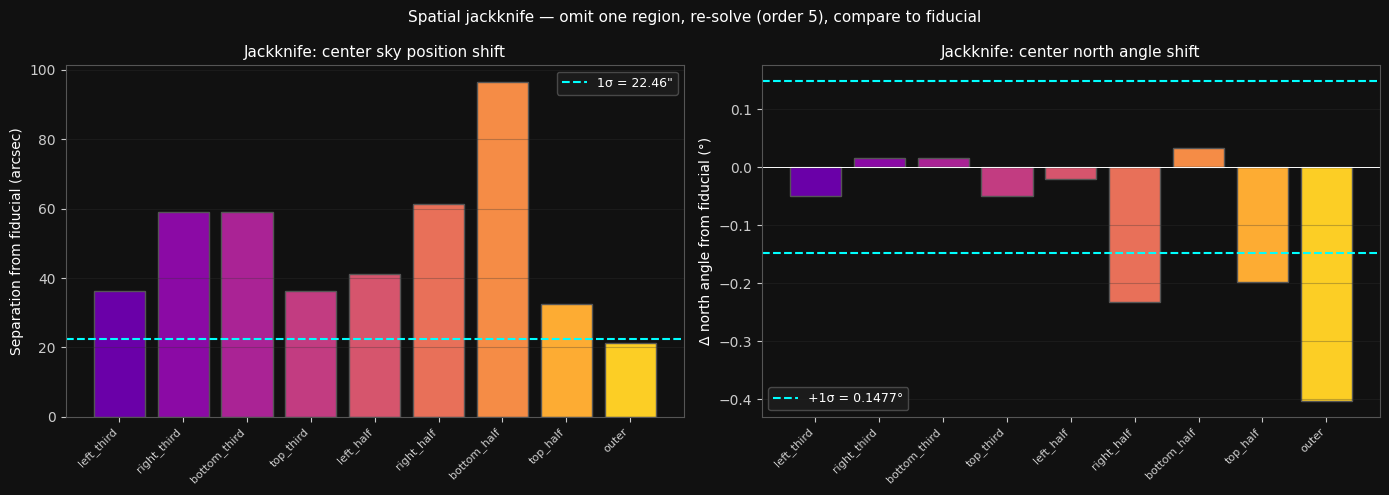

Saved jackknife_shifts.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ok_df = jk_df[jk_df.status == 'ok'].reset_index(drop=True)
short_labels = [l.replace('omit_', '') for l in ok_df['label']]

ax = axes[0]
colors_sep = plt.cm.plasma(np.linspace(0.2, 0.9, len(ok_df)))
bars = ax.bar(short_labels, ok_df['sep_arcsec'], color=colors_sep, edgecolor='#555')
ax.axhline(jk_systematic_sep_as, color='cyan', lw=1.5, linestyle='--',
           label=f'1σ = {jk_systematic_sep_as:.2f}"')
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Separation from fiducial (arcsec)')
ax.set_title('Jackknife: center sky position shift')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
colors_th = plt.cm.plasma(np.linspace(0.2, 0.9, len(ok_df)))
ax2.bar(short_labels, ok_df['dtheta_deg'], color=colors_th, edgecolor='#555')
ax2.axhline(0, color='white', lw=0.7)
ax2.axhline( jk_systematic_theta_deg, color='cyan', lw=1.5, linestyle='--',
            label=f'+1σ = {jk_systematic_theta_deg:.4f}°')
ax2.axhline(-jk_systematic_theta_deg, color='cyan', lw=1.5, linestyle='--')
ax2.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Δ north angle from fiducial (°)')
ax2.set_title('Jackknife: center north angle shift')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Spatial jackknife — omit one region, re-solve (order 5), compare to fiducial',
             fontsize=11)
fig.tight_layout()
_out = OUT_DIR / 'jackknife_shifts.png'
fig.savefig(_out, bbox_inches='tight')
plt.show()
print(f'Saved {_out.name}')

## Section 5 — Bootstrap resampling (N=50, 80% subsets)

80% random subsets without replacement avoid submitting duplicate pixel
coordinates to astrometry.net (which can cause solver confusion). Fixed seed
for reproducibility.

In [18]:
import time as _time
import requests as _requests

N_BOOT      = 50
BOOT_FRAC   = 0.80
BOOT_ORDER  = 5
rng         = np.random.default_rng(42)
n_src_total = len(all_xs)
n_boot_src  = int(n_src_total * BOOT_FRAC)

# Pre-generate all indices so cached re-runs use identical subsets.
boot_indices = [rng.choice(n_src_total, size=n_boot_src, replace=False)
                for _ in range(N_BOOT)]

_MAX_RETRIES  = 4
_RETRY_DELAYS = [15, 30, 60, 120]   # seconds between attempts

def _solve_with_retry(sub_x, sub_y, hints, cache):
    """platesolve_xylist with retry on transient network disconnects."""
    for attempt in range(_MAX_RETRIES):
        try:
            return platesolve_xylist(
                sub_x, sub_y, nx, ny,
                original_header=orig_header,
                hints=hints,
                fetch_products=False,
                cache=cache,
                verbose=False,
            )
        except (_requests.exceptions.ConnectionError,
                _requests.exceptions.Timeout,
                ConnectionError,
                OSError) as exc:
            if attempt == _MAX_RETRIES - 1:
                print(f'[give up after {_MAX_RETRIES} attempts: {type(exc).__name__}]')
                return None
            delay = _RETRY_DELAYS[attempt]
            print(f'[attempt {attempt+1} network error, retry in {delay}s: '
                  f'{str(exc)[:60]}]')
            _time.sleep(delay)
    return None

boot_results = []
for i, idx in enumerate(boot_indices):
    cache  = OUT_DIR / f'solve_order{BOOT_ORDER}_bootstrap_{i:03d}.pkl'
    sub_x, sub_y = all_xs[idx], all_ys[idx]
    prefix = f'Bootstrap {i:02d}/{N_BOOT}  (N={n_boot_src})'

    if cache.exists():
        with open(cache, 'rb') as fh:
            result = pickle.load(fh)
        m = eval_center(result) if result is not None else None
        tag = f'RA={m["ra_deg"]:.5f}  theta={m["theta_deg"]:.4f}°' if m else 'FAILED (cached)'
        print(f'{prefix}  [cached]  {tag}')
        boot_results.append({'idx': i, 'result': result, 'metrics': m})
    else:
        print(f'{prefix}  ', end='', flush=True)
        hints  = dict(**HINTS_BASE, tweak_order=BOOT_ORDER)
        result = _solve_with_retry(sub_x, sub_y, hints, cache)
        m = eval_center(result) if result is not None else None
        print(f'RA={m["ra_deg"]:.5f}  theta={m["theta_deg"]:.4f}°' if m else 'FAILED')
        boot_results.append({'idx': i, 'result': result, 'metrics': m})
        time.sleep(30)


n_ok = sum(1 for b in boot_results if b['metrics'] is not None)
print(f'\n{n_ok}/{N_BOOT} bootstrap solves succeeded.')


Bootstrap 00/50  (N=204)  [cached]  RA=113.42479  theta=-107.0416°
Bootstrap 01/50  (N=204)  [cached]  RA=113.43625  theta=-107.1175°
Bootstrap 02/50  (N=204)  [cached]  RA=113.42250  theta=-107.0938°
Bootstrap 03/50  (N=204)  [cached]  RA=113.43162  theta=-107.2146°
Bootstrap 04/50  (N=204)  [cached]  RA=113.42947  theta=-107.0633°
Bootstrap 05/50  (N=204)  [cached]  RA=113.42068  theta=-106.9711°
Bootstrap 06/50  (N=204)  [cached]  RA=113.41851  theta=-106.8982°
Bootstrap 07/50  (N=204)  [cached]  RA=113.42629  theta=-106.9710°
Bootstrap 08/50  (N=204)  RA=113.42068  theta=-106.9711°
Bootstrap 09/50  (N=204)  RA=113.42344  theta=-107.1830°
Bootstrap 10/50  (N=204)  RA=113.41977  theta=-106.9044°
Bootstrap 11/50  (N=204)  RA=113.42395  theta=-106.9099°
Bootstrap 12/50  (N=204)  [attempt 1 network error, retry in 15s: ('Connection aborted.', RemoteDisconnected('Remote end close]
RA=113.41136  theta=-107.0719°
Bootstrap 13/50  (N=204)  [attempt 1 network error, retry in 15s: ('Connectio

KeyboardInterrupt: 

In [19]:
boot_rows = []
for b in boot_results:
    m = b['metrics']
    if m is None:
        boot_rows.append({'i': b['idx'], 'ra_deg': np.nan, 'dec_deg': np.nan,
                          'theta_deg': np.nan, 'sep_arcsec': np.nan, 'dtheta_deg': np.nan})
        continue
    row = dict(i=b['idx'], ra_deg=m['ra_deg'], dec_deg=m['dec_deg'],
               theta_deg=m['theta_deg'])
    if ref5 is not None:
        sky_b = SkyCoord(ra=m['ra_deg']*u.deg, dec=m['dec_deg']*u.deg)
        sky_r = SkyCoord(ra=ref5['ra_deg']*u.deg, dec=ref5['dec_deg']*u.deg)
        row['sep_arcsec'] = float(sky_b.separation(sky_r).arcsec)
        row['dtheta_deg'] = float(angle_diff_deg(m['theta_deg'], ref5['theta_deg']))
    else:
        row['sep_arcsec'] = np.nan
        row['dtheta_deg'] = np.nan
    boot_rows.append(row)

boot_df = pd.DataFrame(boot_rows)
boot_ok  = boot_df.dropna(subset=['sep_arcsec'])

boot_sep_std   = float(boot_ok['sep_arcsec'].std()) if len(boot_ok) > 1 else float('nan')
boot_theta_std = float(boot_ok['dtheta_deg'].std()) if len(boot_ok) > 1 else float('nan')
boot_ra_std_as  = float(boot_ok['ra_deg'].std() * 3600
                         * np.cos(np.radians(boot_ok['dec_deg'].mean()))) if len(boot_ok)>1 else float('nan')
boot_dec_std_as = float(boot_ok['dec_deg'].std() * 3600) if len(boot_ok)>1 else float('nan')

print(f'Bootstrap statistics  (N_ok={len(boot_ok)}):')
print(f'  sep  std : {boot_sep_std:.3f} arcsec')
print(f'  RA   std : {boot_ra_std_as:.3f} arcsec (×cosδ)')
print(f'  Dec  std : {boot_dec_std_as:.3f} arcsec')
print(f'  theta std: {boot_theta_std:.5f}°')

Bootstrap statistics  (N_ok=17):
  sep  std : 35.684 arcsec
  RA   std : 25.282 arcsec (×cosδ)
  Dec  std : 54.636 arcsec
  theta std: 0.09945°


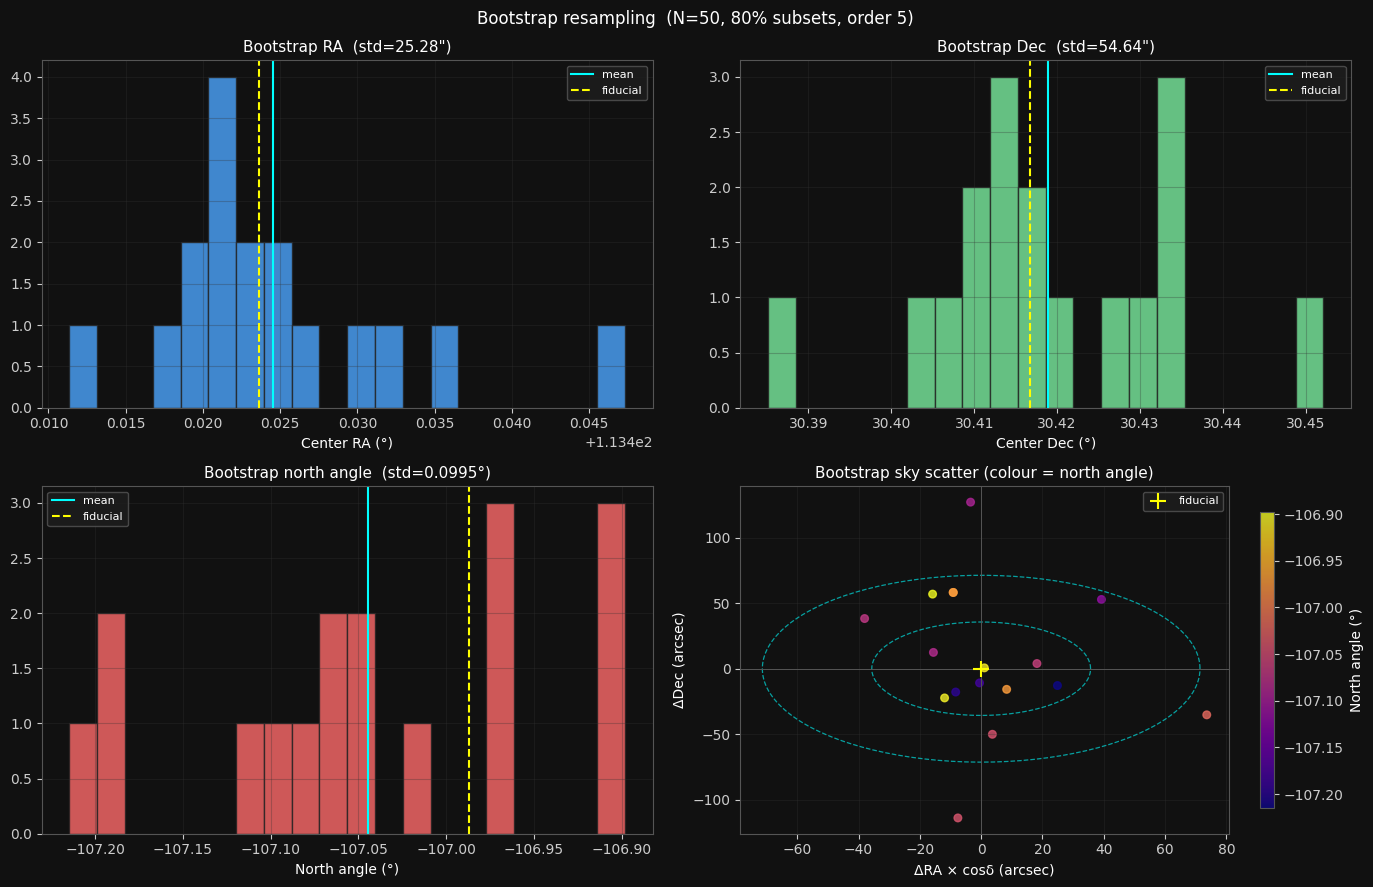

Saved bootstrap_distributions.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# RA histogram
ax = axes[0][0]
ax.hist(boot_ok['ra_deg'], bins=20, color='#4da6ff', edgecolor='#222', alpha=0.8)
ax.axvline(boot_ok['ra_deg'].mean(), color='cyan', lw=1.5, label='mean')
if ref5: ax.axvline(ref5['ra_deg'], color='yellow', lw=1.5, linestyle='--', label='fiducial')
ax.set_xlabel('Center RA (°)')
ax.set_title(f'Bootstrap RA  (std={boot_ra_std_as:.2f}")')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Dec histogram
ax = axes[0][1]
ax.hist(boot_ok['dec_deg'], bins=20, color='#7bed9f', edgecolor='#222', alpha=0.8)
ax.axvline(boot_ok['dec_deg'].mean(), color='cyan', lw=1.5, label='mean')
if ref5: ax.axvline(ref5['dec_deg'], color='yellow', lw=1.5, linestyle='--', label='fiducial')
ax.set_xlabel('Center Dec (°)')
ax.set_title(f'Bootstrap Dec  (std={boot_dec_std_as:.2f}")')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# North angle histogram
ax = axes[1][0]
ax.hist(boot_ok['theta_deg'], bins=20, color='#ff6b6b', edgecolor='#222', alpha=0.8)
ax.axvline(boot_ok['theta_deg'].mean(), color='cyan', lw=1.5, label='mean')
if ref5: ax.axvline(ref5['theta_deg'], color='yellow', lw=1.5, linestyle='--', label='fiducial')
ax.set_xlabel('North angle (°)')
ax.set_title(f'Bootstrap north angle  (std={boot_theta_std:.4f}°)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Sky scatter: RA vs Dec offset from fiducial
ax = axes[1][1]
if ref5:
    dra_as_arr  = (boot_ok['ra_deg'] - ref5['ra_deg']) * 3600 * np.cos(np.radians(ref5['dec_deg']))
    ddec_as_arr = (boot_ok['dec_deg'] - ref5['dec_deg']) * 3600
    sc = ax.scatter(dra_as_arr, ddec_as_arr, c=boot_ok['theta_deg'],
                    cmap='plasma', s=30, alpha=0.8)
    plt.colorbar(sc, ax=ax, label='North angle (°)', shrink=0.85)
    theta = np.linspace(0, 2*np.pi, 200)
    for r in [boot_sep_std, 2*boot_sep_std]:
        ax.plot(r*np.cos(theta), r*np.sin(theta), '--', color='cyan', lw=0.9, alpha=0.6)
    ax.axhline(0, color='#555', lw=0.7)
    ax.axvline(0, color='#555', lw=0.7)
    ax.scatter([0], [0], marker='+', color='yellow', s=120, zorder=5, label='fiducial')
    ax.set_xlabel('ΔRA × cosδ (arcsec)')
    ax.set_ylabel('ΔDec (arcsec)')
    ax.legend(fontsize=8)
ax.set_title('Bootstrap sky scatter (colour = north angle)')
ax.grid(alpha=0.3)

fig.suptitle(f'Bootstrap resampling  (N={N_BOOT}, {int(BOOT_FRAC*100)}% subsets, order {BOOT_ORDER})',
             fontsize=12)
fig.tight_layout()
_out = OUT_DIR / 'bootstrap_distributions.png'
fig.savefig(_out, bbox_inches='tight')
plt.show()
print(f'Saved {_out.name}')

## Section 6 — Residual vector field

Evaluate each bootstrap WCS on a grid of pixel positions, compare to the
fiducial (order-5, full source list) WCS. Quiver plot shows the mean sky
offset vector at each grid point; heatmap shows RMS deviation magnitude.

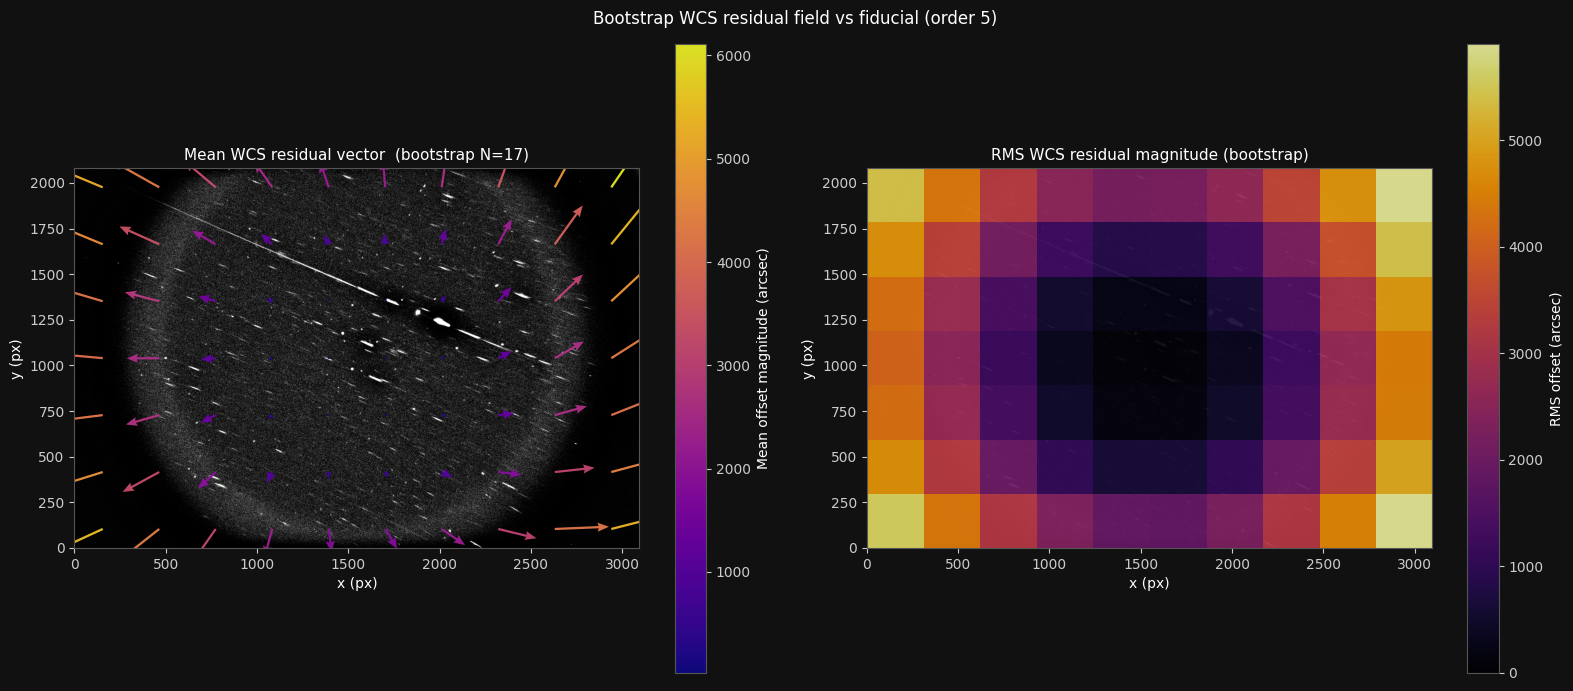

Saved residual_vector_field.png


In [21]:
N_GRID_X, N_GRID_Y = 10, 7
gx = np.linspace(nx * 0.05, nx * 0.95, N_GRID_X)
gy = np.linspace(ny * 0.05, ny * 0.95, N_GRID_Y)
GX, GY = np.meshgrid(gx, gy)     # (N_GRID_Y, N_GRID_X)
pts = np.column_stack([GX.ravel(), GY.ravel()])   # (N_pts, 2)

ref_wcs = wcs_from_result(fiducial_results.get(5)) if fiducial_results.get(5) else None

if ref_wcs is not None:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ref_sky = ref_wcs.all_pix2world(pts, 0)  # (N_pts, 2): RA, Dec in deg

    # Accumulate offsets across bootstrap solves
    dra_all  = []   # arcsec ×cosδ
    ddec_all = []
    for b in boot_results:
        if b['result'] is None:
            continue
        bwcs = wcs_from_result(b['result'])
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            b_sky = bwcs.all_pix2world(pts, 0)
        cosd = np.cos(np.radians(ref_sky[:, 1]))
        dra  = (b_sky[:, 0] - ref_sky[:, 0]) * cosd * 3600
        ddec = (b_sky[:, 1] - ref_sky[:, 1]) * 3600
        dra_all.append(dra)
        ddec_all.append(ddec)

    dra_arr  = np.array(dra_all)   # (N_ok, N_pts)
    ddec_arr = np.array(ddec_all)
    mean_dra  = dra_arr.mean(axis=0).reshape(N_GRID_Y, N_GRID_X)
    mean_ddec = ddec_arr.mean(axis=0).reshape(N_GRID_Y, N_GRID_X)
    rms_sep   = np.sqrt(dra_arr**2 + ddec_arr**2).mean(axis=0).reshape(N_GRID_Y, N_GRID_X)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Quiver: mean offset direction and magnitude
    ax = axes[0]
    ax.imshow(disp, origin='lower', cmap='gray', vmin=_vlo, vmax=_vhi, aspect='equal')
    mag = np.hypot(mean_dra, mean_ddec)
    qsc = ax.quiver(GX, GY, mean_dra, mean_ddec, mag,
                    cmap='plasma', scale=None, scale_units='inches',
                    width=0.004, headwidth=4, headlength=5, alpha=0.9)
    plt.colorbar(qsc, ax=ax, label='Mean offset magnitude (arcsec)')
    ax.set_title(f'Mean WCS residual vector  (bootstrap N={len(dra_all)})')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

    # Heatmap: RMS deviation at each grid point
    ax2 = axes[1]
    ax2.imshow(disp, origin='lower', cmap='gray', vmin=_vlo, vmax=_vhi,
               aspect='equal', alpha=0.4)
    im = ax2.imshow(rms_sep, origin='lower', cmap='inferno', alpha=0.85,
                    extent=[-0.5, nx-0.5, -0.5, ny-0.5], aspect='equal',
                    vmin=0, vmax=np.nanpercentile(rms_sep, 98))
    plt.colorbar(im, ax=ax2, label='RMS offset (arcsec)')
    ax2.set_title('RMS WCS residual magnitude (bootstrap)')
    ax2.set_xlabel('x (px)'); ax2.set_ylabel('y (px)')

    fig.suptitle('Bootstrap WCS residual field vs fiducial (order 5)', fontsize=12)
    fig.tight_layout()
    _out = OUT_DIR / 'residual_vector_field.png'
    fig.savefig(_out, bbox_inches='tight')
    plt.show()
    print(f'Saved {_out.name}')
else:
    print('No fiducial WCS — skipping vector field.')

## Section 7 — Final summary

Adopted uncertainties are the quadrature sum of the three independent
contributors:
```
σ_theta = sqrt(σ_bootstrap² + σ_order_systematic² + σ_jackknife²)
σ_sky   = sqrt(σ_bootstrap² + σ_order_systematic² + σ_jackknife²)
```

In [22]:
adopted_theta = np.sqrt(boot_theta_std**2
                        + order_systematic_theta_deg**2
                        + jk_systematic_theta_deg**2)
adopted_sep   = np.sqrt(boot_sep_std**2
                        + order_systematic_sep_as**2
                        + jk_systematic_sep_as**2)

summary = pd.DataFrame([
    {'component': 'Bootstrap std',
     'sep_arcsec': boot_sep_std,
     'theta_deg':  boot_theta_std},
    {'component': 'Order systematic (4 vs 5)',
     'sep_arcsec': order_systematic_sep_as,
     'theta_deg':  order_systematic_theta_deg},
    {'component': 'Jackknife std',
     'sep_arcsec': jk_systematic_sep_as,
     'theta_deg':  jk_systematic_theta_deg},
    {'component': '──────────────',
     'sep_arcsec': np.nan, 'theta_deg': np.nan},
    {'component': 'ADOPTED (quadrature)',
     'sep_arcsec': adopted_sep,
     'theta_deg':  adopted_theta},
])

print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
summary.to_csv(OUT_DIR / 'wcs_uncertainty_summary.csv', index=False)

print(f'\nAdopted WCS center uncertainty:')
print(f'  Sky position : {adopted_sep:.2f} arcsec  (1σ)')
print(f'  North angle  : {adopted_theta:.4f}°  (1σ = {adopted_theta*60:.2f} arcmin)')

                component  sep_arcsec  theta_deg
            Bootstrap std     35.6844     0.0995
Order systematic (4 vs 5)      6.9759     0.1293
            Jackknife std     22.4555     0.1477
           ──────────────         NaN        NaN
     ADOPTED (quadrature)     42.7351     0.2201

Adopted WCS center uncertainty:
  Sky position : 42.74 arcsec  (1σ)
  North angle  : 0.2201°  (1σ = 13.20 arcmin)


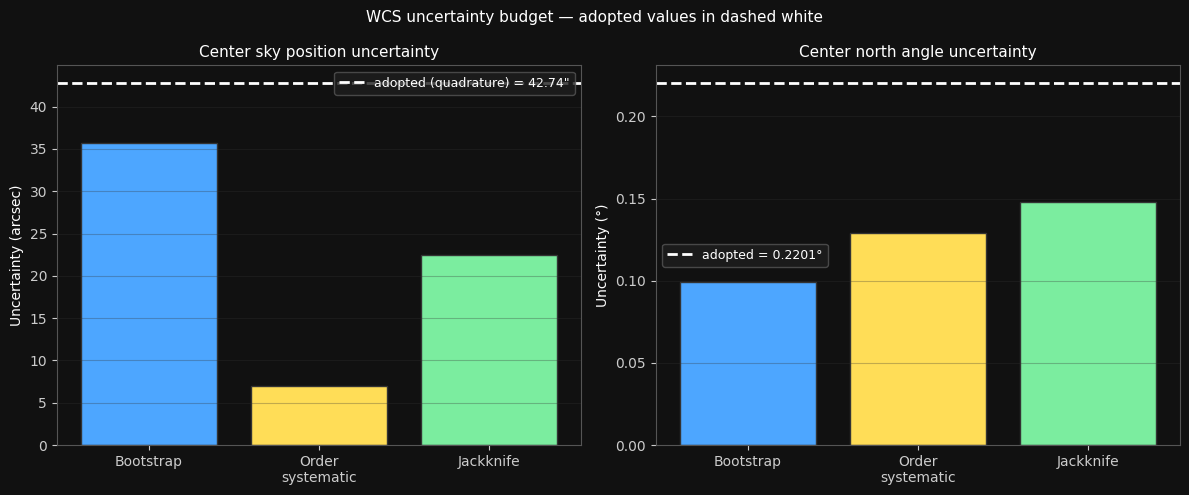

Saved uncertainty_budget.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

components = ['Bootstrap', 'Order\nsystematic', 'Jackknife']
sep_vals   = [boot_sep_std, order_systematic_sep_as, jk_systematic_sep_as]
theta_vals = [boot_theta_std, order_systematic_theta_deg, jk_systematic_theta_deg]
_cols      = ['#4da6ff', '#ffdd57', '#7bed9f']

ax = axes[0]
bars = ax.bar(components, sep_vals, color=_cols, edgecolor='#333')
ax.axhline(adopted_sep, color='white', lw=2, linestyle='--',
           label=f'adopted (quadrature) = {adopted_sep:.2f}"')
ax.set_ylabel('Uncertainty (arcsec)')
ax.set_title('Center sky position uncertainty')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.bar(components, theta_vals, color=_cols, edgecolor='#333')
ax2.axhline(adopted_theta, color='white', lw=2, linestyle='--',
            label=f'adopted = {adopted_theta:.4f}°')
ax2.set_ylabel('Uncertainty (°)')
ax2.set_title('Center north angle uncertainty')
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

fig.suptitle('WCS uncertainty budget — adopted values in dashed white', fontsize=11)
fig.tight_layout()
_out = OUT_DIR / 'uncertainty_budget.png'
fig.savefig(_out, bbox_inches='tight')
plt.show()
print(f'Saved {_out.name}')